In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

In [2]:
raw_data = pd.read_csv("/kaggle/input/student-performance-data-set/student-mat.csv", delimiter=';')

In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
raw_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
print(raw_data.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


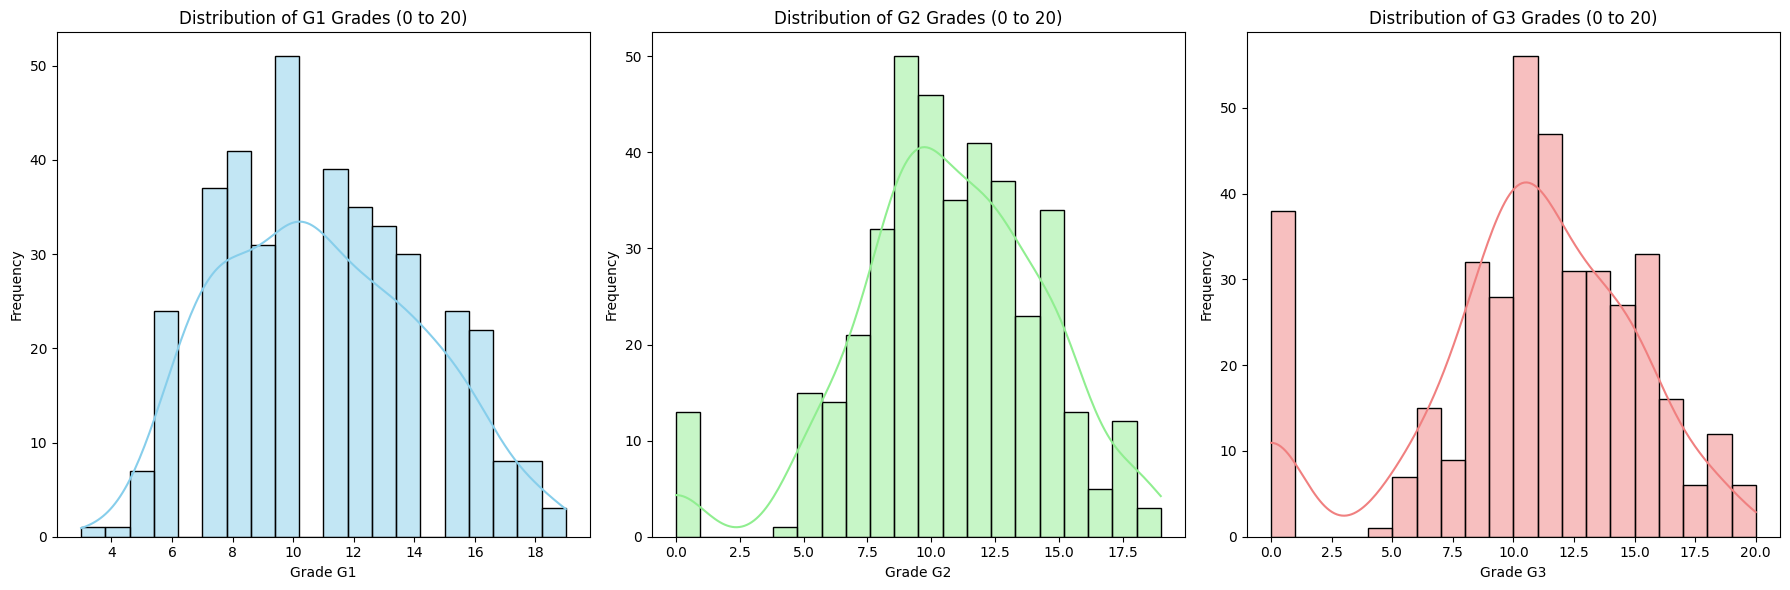

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(raw_data['G1'], kde=True, bins=20, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of G1 Grades (0 to 20)')
axes[0].set_xlabel('Grade G1')
axes[0].set_ylabel('Frequency')

sns.histplot(raw_data['G2'], kde=True, bins=20, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribution of G2 Grades (0 to 20)')
axes[1].set_xlabel('Grade G2')
axes[1].set_ylabel('Frequency')

sns.histplot(raw_data['G3'], kde=True, bins=20, color='lightcoral', ax=axes[2])
axes[2].set_title('Distribution of G3 Grades (0 to 20)')
axes[2].set_xlabel('Grade G3')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
pd.set_option("display.max_columns",35)

In [8]:
raw_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [9]:
duplicates = raw_data.duplicated()
raw_data[duplicates].sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: object

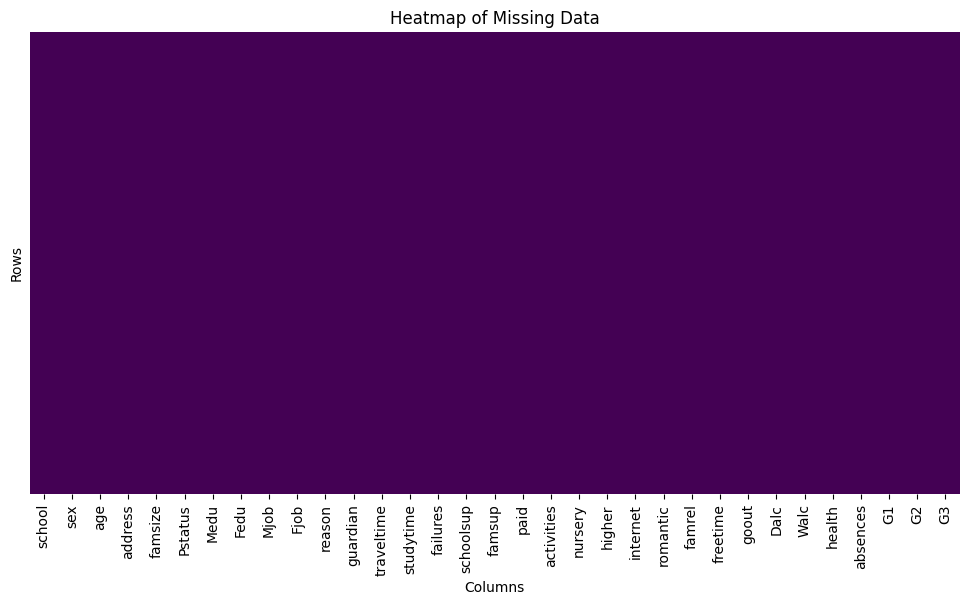

In [10]:
missing_data = raw_data.isnull()
plt.figure(figsize=(12, 6))
sns.heatmap(missing_data, cbar=False, cmap='viridis', yticklabels=False, xticklabels=raw_data.columns)
plt.title('Heatmap of Missing Data')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [11]:
raw_data.drop(['school','address','age','sex'], axis=1, inplace=True)

In [12]:
binary_cols = ['famsize','Pstatus', 'famsup', 'paid', 'activities','nursery', 'higher', 'internet', 'romantic','schoolsup', 'Fjob','guardian','reason','Mjob']

In [13]:
binary_map = {'yes': 1, 'no': 0,'GT3':1,'LE3':0,'A':1,'T':0,'father':1,'mother':0, 'other':3,
              'course': 0 ,'home':1,'reputation':2, 'at_home':0, 'health':1, 'services':2,'teacher':4}
for col in binary_cols:
    if set(raw_data[col].unique()).issubset(binary_map.keys()):
        raw_data[col] = raw_data[col].map(binary_map)

In [14]:
raw_data['Fjob'].unique(), raw_data['Mjob'].unique()

(array([4, 3, 2, 1, 0]), array([0, 1, 3, 2, 4]))

In [15]:
raw_data['guardian'].unique()

array([0, 1, 3])

In [16]:
raw_data['Mjob'].unique()

array([0, 1, 3, 2, 4])

In [17]:
raw_data['reason'].unique()

array([0, 3, 1, 2])

In [18]:
raw_data.head()

,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,1,1,4,4,0,4,0,0,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6
1,1,0,1,1,0,3,0,1,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6
2,0,0,1,1,0,3,3,0,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10
3,1,0,4,2,1,2,1,0,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15
4,1,0,3,3,3,3,1,1,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10


In [19]:
means = raw_data.mean()
std_devs = raw_data.std()
z_scores = (raw_data - means) / std_devs
threshold = 4

outliers = raw_data[(z_scores.abs() > threshold).any(axis=1)]

print(f"Number of outliers: {len(outliers)}")
if not outliers.empty:
    print("\nIndices of outliers:")
    print(outliers.index.tolist())
    print("\nSample of outliers:")
    print(outliers.head())
else:
    print("No outliers detected.")

Number of outliers: 24

Indices of outliers:
[74, 78, 127, 148, 150, 153, 160, 163, 164, 165, 166, 183, 239, 247, 250, 252, 269, 276, 307, 311, 315, 352, 361, 371]

Sample of outliers:
     famsize  Pstatus  Medu  Fedu  Mjob  Fjob  reason  guardian  traveltime  \
74         1        0     3     3     3     2       1         0           1   
78         1        0     2     1     3     3       1         0           2   
127        1        0     0     1     0     3       0         3           1   
148        1        0     4     4     4     4       0         0           1   
150        0        0     1     1     3     3       0         0           1   

     studytime  failures  schoolsup  famsup  paid  activities  nursery  \
74           2         0          1       1     1           1        1   
78           1         3          1       1     0           1        1   
127          2         3          0       1     0           0        0   
148          1         0          0       1 

In [20]:
features = raw_data.drop(columns='G3')
scaler = MinMaxScaler()

normalized_features = scaler.fit_transform(features)
ready_data = pd.DataFrame(normalized_features, columns=features.columns)
ready_data['G3'] = raw_data['G3']

In [21]:
ready_data.head()

,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,1.0,1.0,1.00,1.00,0.00,1.00,0.000000,0.000000,0.333333,0.333333,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.75,0.50,0.75,0.00,0.00,0.5,0.080000,0.1250,0.315789,6
1,1.0,0.0,0.25,0.25,0.00,0.75,0.000000,0.333333,0.000000,0.333333,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.00,0.50,0.50,0.00,0.00,0.5,0.053333,0.1250,0.263158,6
2,0.0,0.0,0.25,0.25,0.00,0.75,1.000000,0.000000,0.000000,0.333333,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.75,0.50,0.25,0.25,0.50,0.5,0.133333,0.2500,0.421053,10
3,1.0,0.0,1.00,0.50,0.25,0.50,0.333333,0.000000,0.000000,0.666667,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.50,0.25,0.25,0.00,0.00,1.0,0.026667,0.7500,0.736842,15
4,1.0,0.0,0.75,0.75,0.75,0.75,0.333333,0.333333,0.000000,0.333333,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.75,0.50,0.25,0.00,0.25,1.0,0.053333,0.1875,0.526316,10


# The dataset is ready to use!